In [4]:
import numpy as np
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import spearmanr
import pandas as pd

 50 条真实 Cas12a 错配数据集

In [7]:
data = [
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "AGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.244067,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "GGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.536652,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "TGGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 0,
        "relative_activity": 1.349063,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CAGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.002632,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CCGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.327277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CTGTTCGCGTGGATTAAAGG",
        "mismatch_pos": 1,
        "relative_activity": 1.293087,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGATTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.108303,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGCTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.294277,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGTTTCGCGTGGATTAAAGG",
        "mismatch_pos": 2,
        "relative_activity": 1.230956,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGATCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.275075,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGCTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.259007,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGGTCGCGTGGATTAAAGG",
        "mismatch_pos": 3,
        "relative_activity": 1.422551,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTACGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.206470,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTCCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.287469,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTGCGCGTGGATTAAAGG",
        "mismatch_pos": 4,
        "relative_activity": 1.460275,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTAGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.150048,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTGGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.344187,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTTGCGTGGATTAAAGG",
        "mismatch_pos": 5,
        "relative_activity": 1.151763,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCACGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 0.966740,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCCCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.109856,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCTCGTGGATTAAAGG",
        "mismatch_pos": 6,
        "relative_activity": 1.107226,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGAGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.085175,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGGGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.202152,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGTGTGGATTAAAGG",
        "mismatch_pos": 7,
        "relative_activity": 1.058207,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCATGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.037646,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCCTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.133941,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCTTGGATTAAAGG",
        "mismatch_pos": 8,
        "relative_activity": 1.131164,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGAGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.108452,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGCGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.241383,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGGGGATTAAAGG",
        "mismatch_pos": 9,
        "relative_activity": 1.171693,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTAGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.054520,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTCGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.267676,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTTGATTAAAGG",
        "mismatch_pos": 10,
        "relative_activity": 1.222937,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGAATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 0.994914,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGCATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.275432,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGTATTAAAGG",
        "mismatch_pos": 11,
        "relative_activity": 1.181162,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGCTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.315327,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGGTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.241909,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGTTTAAAGG",
        "mismatch_pos": 12,
        "relative_activity": 1.321736,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAATAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.173173,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGACTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.114124,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGAGTAAAGG",
        "mismatch_pos": 13,
        "relative_activity": 1.276508,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATAAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.171015,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATCAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.209477,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATGAAAGG",
        "mismatch_pos": 14,
        "relative_activity": 1.376292,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTCAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.349096,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTGAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.274115,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTTAAGG",
        "mismatch_pos": 15,
        "relative_activity": 1.199478,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTACAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.355353,
    },
    {
        "spacer_seq": "CGGUUCGCGUGGAUUAAAGG",
        "target_seq": "CGGTTCGCGTGGATTAGAGG",
        "mismatch_pos": 16,
        "relative_activity": 1.332736,
    },
]

df = pd.DataFrame(data)

最终特征提取

In [11]:
def extract_final_features(spacer, target, mismatch_pos):
    """只提取4个核心特征"""
    import RNA
    
    # 1. 杂交自由能
    duplex = RNA.duplexfold(spacer, target)
    dg_duplex = duplex.energy
    
    # 2. 相对完美配对的能量差
    dg_perfect = RNA.duplexfold(spacer, spacer.replace("U", "T")).energy
    ddg = dg_duplex - dg_perfect
    
    # 3. 错配位置
    pos = int(mismatch_pos)
    
    # 4. 错配碱基类型
    sp_base = spacer[pos] if pos < len(spacer) else "N"
    tg_base = target[pos] if pos < len(target) else "N"
    is_purine_mismatch = 1 if (sp_base in ["A", "G"] and tg_base in ["A", "G"]) else 0
    
    # 5. 是否转换突变 (A<->G, C<->T)
    transitions = [("A", "G"), ("G", "A"), ("C", "T"), ("T", "C")]
    is_transition = 1 if (sp_base, tg_base) in transitions else 0
    
    return [pos, ddg, is_purine_mismatch, is_transition]

# ===== 重新提取特征 =====
X_final = np.array([
    extract_final_features(row["spacer_seq"], row["target_seq"], row["mismatch_pos"])
    for _, row in df.iterrows()
])
y = df["relative_activity"].values

# ===== 训练最终集成模型 =====
svr_model = make_pipeline(
    StandardScaler(),
    SVR(kernel="rbf", C=1, epsilon=0.1, gamma="scale")
)

gb_model = GradientBoostingRegressor(
    n_estimators=100, max_depth=2, learning_rate=0.05,
    subsample=0.8, random_state=42
)

# LOO 交叉验证
y_pred_svr = cross_val_predict(svr_model, X_final, y, cv=LeaveOneOut())
y_pred_gb = cross_val_predict(gb_model, X_final, y, cv=LeaveOneOut())
y_pred_final = (y_pred_svr + y_pred_gb) / 2

rho, p = spearmanr(y, y_pred_final)
print(f"最终模型 LOO: r_s = {rho:.3f}, p = {p:.4e}")

# ===== 保存结果用于绘图 =====
results = pd.DataFrame({
    "Actual": y,
    "Predicted": y_pred_final,
    "Residual": y - y_pred_final
})
results.to_csv("final_predictions.csv", index=False)
print("\n预测结果已保存到 final_predictions.csv")

最终模型 LOO: r_s = 0.642, p = 5.0439e-07

预测结果已保存到 final_predictions.csv


In [15]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error, r2_score


y_pred_svr = cross_val_predict(svr_model, X_final, y, cv=LeaveOneOut())
y_pred_gb = cross_val_predict(gb_model, X_final, y, cv=LeaveOneOut())
y_pred_final = (y_pred_svr + y_pred_gb) / 2

# 计算所有指标
rho, p_rho = spearmanr(y, y_pred_final)
r_pearson, p_pearson = pearsonr(y, y_pred_final)
rmse = np.sqrt(mean_squared_error(y, y_pred_final))
r2 = r2_score(y, y_pred_final)

print(f"Spearman r_s = {rho:.3f}, p = {p_rho:.2e}")
print(f"Pearson r = {r_pearson:.3f}, p = {p_pearson:.2e}")
print(f"RMSE = {rmse:.3f}")
print(f"R² = {r2:.3f}")

# 创建结果DataFrame
results = pd.DataFrame({
    'Actual': y,
    'Predicted': y_pred_final,
    'Residual': y - y_pred_final
})

# 保存数据
results.to_csv('model_predictions.csv', index=False)
print("\n数据已保存到 model_predictions.csv")
print("\n前5行预测结果:")
print(results.head())

Spearman r_s = 0.642, p = 5.04e-07
Pearson r = 0.615, p = 2.00e-06
RMSE = 0.095
R² = 0.376

数据已保存到 model_predictions.csv

前5行预测结果:
     Actual  Predicted  Residual
0  1.244067   1.462441 -0.218374
1  1.536652   1.312712  0.223940
2  1.349063   1.264184  0.084879
3  1.002632   1.126145 -0.123513
4  1.327277   1.330015 -0.002738


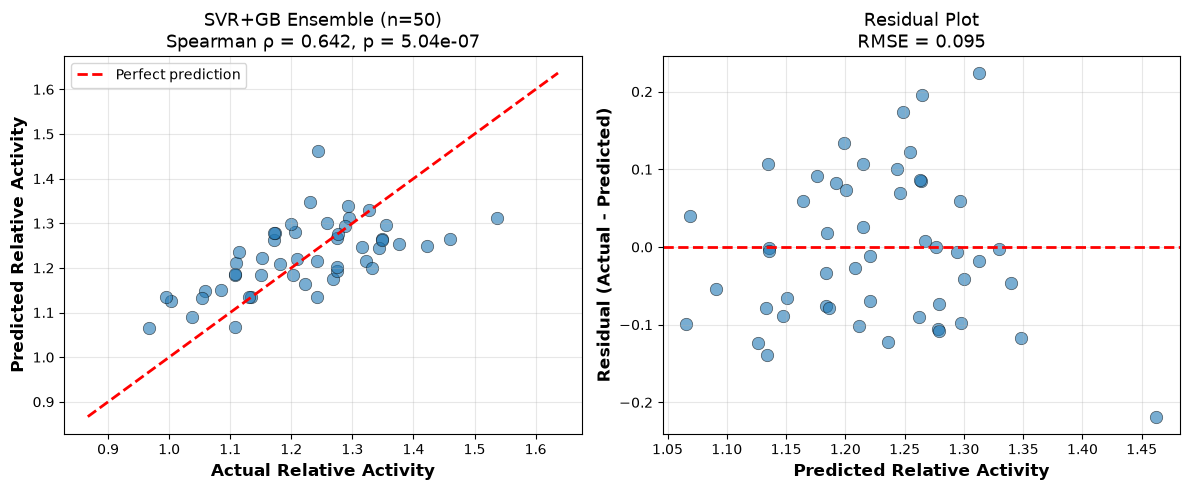

图已保存为 model_performance.png


In [16]:
import matplotlib.pyplot as plt

# 重新计算指标（确保和最新数据一致）
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error
import numpy as np

rho, p_rho = spearmanr(y, y_pred_final)
rmse = np.sqrt(mean_squared_error(y, y_pred_final))

# 创建双图布局
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 左图：实际 vs 预测
ax1 = axes[0]
ax1.scatter(y, y_pred_final, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
lim = [min(y.min(), y_pred_final.min()) - 0.1, max(y.max(), y_pred_final.max()) + 0.1]
ax1.plot(lim, lim, 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Actual Relative Activity', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax1.set_title(f'SVR+GB Ensemble (n=50)\nSpearman ρ = {rho:.3f}, p = {p_rho:.2e}', fontsize=13)
ax1.legend()
ax1.grid(alpha=0.3)

# 右图：残差分布
ax2 = axes[1]
residuals = y - y_pred_final
ax2.scatter(y_pred_final, residuals, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Relative Activity', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residual (Actual - Predicted)', fontsize=12, fontweight='bold')
ax2.set_title(f'Residual Plot\nRMSE = {rmse:.3f}', fontsize=13)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print("图已保存为 model_performance.png")

In [17]:
import pandas as pd
import numpy as np

# 找到最大残差的样本
residuals = y - y_pred_final
max_residual_idx = np.argmax(np.abs(residuals))

print(f"最大残差样本 (index {max_residual_idx}):")
print(f"  实际值: {y[max_residual_idx]:.3f}")
print(f"  预测值: {y_pred_final[max_residual_idx]:.3f}")
print(f"  残差: {residuals[max_residual_idx]:.3f}")
print(f"\n该样本的原始数据:")
print(df.iloc[max_residual_idx])

print(f"\n该样本的4个特征值:")
print(f"  mismatch_pos: {X_final[max_residual_idx, 0]}")
print(f"  ddg: {X_final[max_residual_idx, 1]:.3f}")
print(f"  is_purine_mismatch: {X_final[max_residual_idx, 2]}")
print(f"  is_transition: {X_final[max_residual_idx, 3]}")

# 看看是否是离群特征
print("\n对比特征分布:")
for i, name in enumerate(["mismatch_pos", "ddg", "is_purine_mismatch", "is_transition"]):
    feature_col = X_final[:, i]
    print(f"{name}: 该样本={X_final[max_residual_idx, i]:.2f}, 均值={feature_col.mean():.2f}, 标准差={feature_col.std():.2f}")

最大残差样本 (index 1):
  实际值: 1.537
  预测值: 1.313
  残差: 0.224

该样本的原始数据:
spacer_seq           CGGUUCGCGUGGAUUAAAGG
target_seq           GGGTTCGCGTGGATTAAAGG
mismatch_pos                            0
relative_activity                1.536652
Name: 1, dtype: object

该样本的4个特征值:
  mismatch_pos: 0.0
  ddg: -0.300
  is_purine_mismatch: 0.0
  is_transition: 0.0

对比特征分布:
mismatch_pos: 该样本=0.00, 均值=7.84, 标准差=4.81
ddg: 该样本=-0.30, 均值=1.86, 标准差=2.34
is_purine_mismatch: 该样本=0.00, 均值=0.18, 标准差=0.38
is_transition: 该样本=0.00, 均值=0.24, 标准差=0.43
